# Balearic Islands Tourism — Seasonality, Recovery & Spend
**Author:** Roberto Bustamante Pérez · Data Science student (UOC)

**Business question.** Mallorca, Menorca, Ibiza and Formentera live from tourism, but almost all of it happens in summer.
*How seasonal is the Balearic market compared with Spain's other big destinations, is it growing, and where is the room to grow?*

**Data.** Official statistics from Spain's National Statistics Institute (INE), monthly:
- **EOH** (Hotel Occupancy Survey, table 2074): hotel guests and overnight stays by region and country of residence, 1999–2026.
- **FRONTUR** (table 10823): international tourist arrivals by main destination region, 2015–2026.
- **EGATUR** (table 10839): international tourist spending by main destination region, 2015–2026.

The raw CSVs are cleaned by `etl/build_dataset.py` into a **star schema** (`dim_date`, `dim_region`, `dim_market`,
`fact_hotel`, `fact_international`) stored in DuckDB and CSV, ready for SQL and Power BI.

In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "font.size": 10})
COL = {"Balearic Islands": "#2a78d6", "Canary Islands": "#eb6834", "Spain (total)": "#52514e",
       "Catalonia": "#1baf7a", "Andalusia": "#eda100", "Madrid": "#4a3aa7", "Valencian Community": "#e87ba4"}
IMG = Path("../images"); IMG.mkdir(exist_ok=True)
con = duckdb.connect("../data/processed/tourism.duckdb", read_only=True)
q = lambda s: con.sql(s).df()

hotel = q('''SELECT make_date(d.year, d.month, 1) AS date, d.year, d.month, d.month_name, d.season,
                    r.region, m.market, f.travellers, f.overnight_stays
             FROM fact_hotel f JOIN dim_date d USING (date_key) JOIN dim_region r USING (region_key)
             JOIN dim_market m USING (market_key)''')
intl = q('''SELECT make_date(d.year, d.month, 1) AS date, d.year, d.month, r.region, f.*
            FROM fact_international f JOIN dim_date d USING (date_key) JOIN dim_region r USING (region_key)''')
print(hotel.date.min().date(), "→", hotel.date.max().date(), "|", len(hotel), "hotel rows |", len(intl), "international rows")

1999-01-01 → 2026-08-01 | 6972 hotel rows | 910 international rows


## 1. Data quality checks

In [2]:
print("Missing values:\n", hotel.isna().sum()[lambda s: s > 0], intl.isna().sum()[lambda s: s > 0], sep="\n")
# Consistency check: domestic + international guests should add up to the total
w = hotel.pivot_table(index=["date", "region"], columns="market", values="overnight_stays")
gap = (w["Domestic (Spain)"] + w["International"] - w["All guests"]).abs() / w["All guests"]
print(f"Max relative gap between total and domestic+international: {gap.max():.4%}")
# Coverage of complete years
print(hotel.groupby("year").month.nunique().tail(4))

Missing values:

Series([], dtype: int64)
Series([], dtype: int64)
Max relative gap between total and domestic+international: 0.0034%
year
2023    12
2024    12
2025    12
2026     8
Name: month, dtype: int64


Gaps are only rounding, so the residence split is consistent. **2026 has data up to August**, so yearly comparisons use
2019 (pre-pandemic) and 2025 (last complete year).

## 2. The Balearic Islands in context (2025)

In [3]:
h25 = hotel.query("market == 'All guests' and year == 2025").groupby("region").overnight_stays.sum()
i25 = intl.query("year == 2025").groupby("region")[["tourists", "spend_meur"]].sum()
ctx = pd.DataFrame({"hotel_nights_m": h25 / 1e6, "intl_tourists_m": i25.tourists / 1e6, "intl_spend_bn_eur": i25.spend_meur / 1e3})
ctx["share_of_spain_nights_%"] = 100 * ctx.hotel_nights_m / ctx.loc["Spain (total)", "hotel_nights_m"]
ctx.sort_values("hotel_nights_m", ascending=False).round(1)

,hotel_nights_m,intl_tourists_m,intl_spend_bn_eur,share_of_spain_nights_%
region,,,,
Spain (total),366.1,96.8,134.7,100.0
Canary Islands,73.0,15.7,24.4,19.9
Balearic Islands,63.4,15.7,21.1,17.3
Catalonia,60.6,20.0,24.8,16.5
Andalusia,57.1,14.4,20.0,15.6
Valencian Community,31.5,12.4,16.0,8.6
Madrid,27.5,9.1,17.9,7.5


## 3. How seasonal is it?

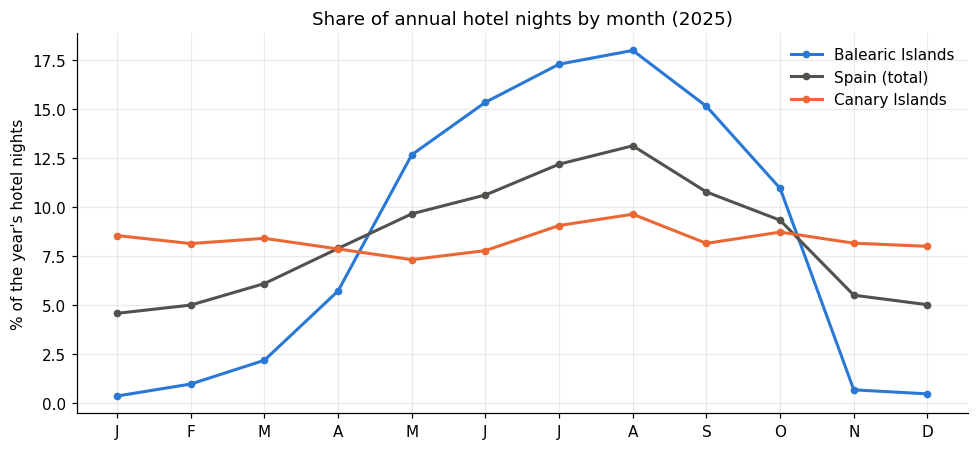

Share of the year's hotel nights in Jun–Sep:
 region
Balearic Islands       65.9
Catalonia              50.4
Spain (total)          46.8
Andalusia              46.5
Valencian Community    45.1
Canary Islands         34.7
Madrid                 33.5


In [4]:
prof = (hotel.query("market == 'All guests' and year == 2025")
             .groupby(["region", "month"]).overnight_stays.sum().groupby(level=0).transform(lambda s: 100 * s / s.sum())
             .unstack(0))
fig, ax = plt.subplots(figsize=(9, 4.2))
for r in ["Balearic Islands", "Spain (total)", "Canary Islands"]:
    ax.plot(prof.index, prof[r], marker="o", lw=2, ms=4, color=COL[r], label=r)
ax.set(xticks=range(1, 13), xticklabels=list("JFMAMJJASOND"), ylabel="% of the year's hotel nights",
       title="Share of annual hotel nights by month (2025)")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(IMG / "seasonality.png"); plt.show()
peak = prof.loc[6:9].sum().sort_values(ascending=False).round(1)
print("Share of the year's hotel nights in Jun–Sep:\n", peak.to_string())

**Two thirds (≈66%) of all Balearic hotel nights happen in just four months**, against ≈47% for Spain and ≈35% for the
Canary Islands. In January the islands sell ~48× fewer hotel nights than in August.

## 4. Recovery: back above 2019?

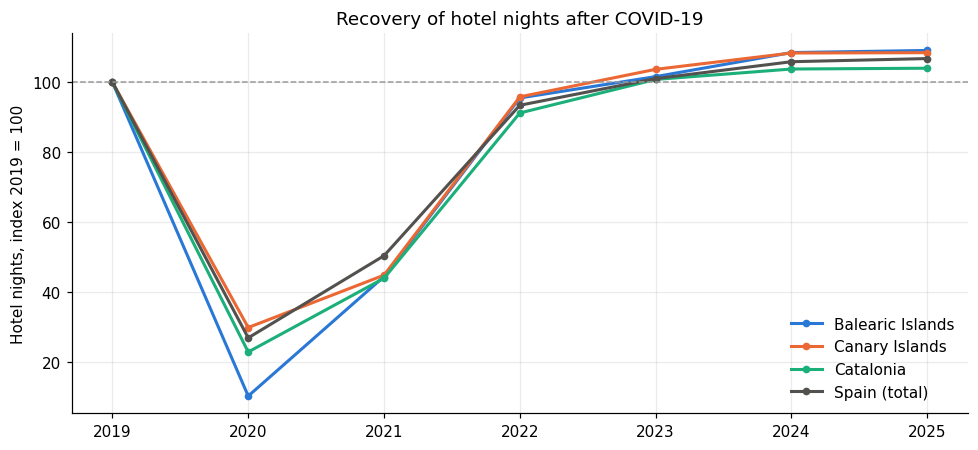

year,2020,2023,2025
region,,,
Balearic Islands,10.3,101.6,109.1
Canary Islands,29.8,103.7,108.4
Madrid,29.0,98.5,107.0
Spain (total),26.9,101.0,106.7
Valencian Community,29.3,97.6,105.7
Andalusia,30.7,98.8,104.2
Catalonia,22.9,100.8,104.0


In [5]:
yr = (hotel.query("market == 'All guests' and 2019 <= year <= 2025")
           .groupby(["region", "year"]).overnight_stays.sum().unstack(0))
idx = 100 * yr / yr.loc[2019]
fig, ax = plt.subplots(figsize=(9, 4.2))
for r in ["Balearic Islands", "Canary Islands", "Catalonia", "Spain (total)"]:
    ax.plot(idx.index, idx[r], marker="o", lw=2, ms=4, color=COL[r], label=r)
ax.axhline(100, color="#999", lw=1, ls="--")
ax.set(ylabel="Hotel nights, index 2019 = 100", title="Recovery of hotel nights after COVID-19")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(IMG / "recovery.png"); plt.show()
idx.loc[[2020, 2023, 2025]].T.round(1).sort_values(2025, ascending=False)

## 5. Where did the growth come from? Month by month, 2025 vs 2019

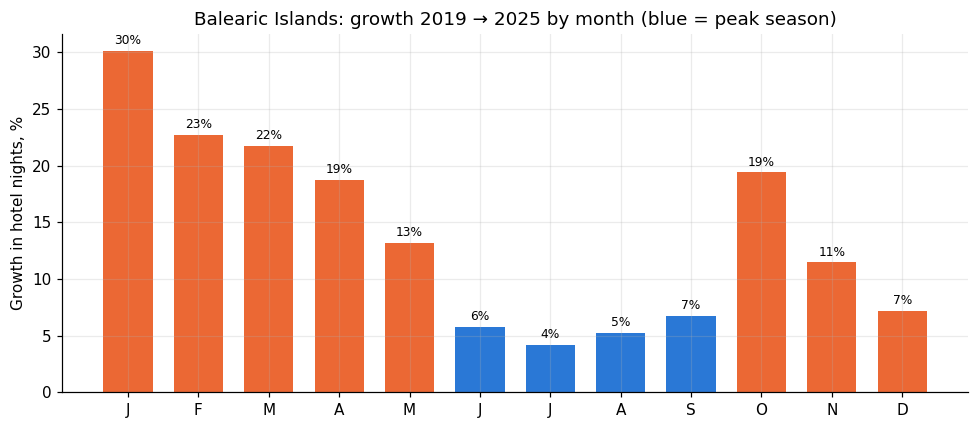

Peak season (Jun–Sep) growth: 5.4%   |   Rest of the year: 16.9%


In [6]:
b = hotel.query("market == 'All guests' and region == 'Balearic Islands' and year in (2019, 2025)")
g = b.pivot_table(index="month", columns="year", values="overnight_stays", aggfunc="sum")
g["growth_%"] = 100 * (g[2025] / g[2019] - 1)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2a78d6" if m in (6, 7, 8, 9) else "#eb6834" for m in g.index]
ax.bar(g.index, g["growth_%"], color=colors, width=.7)
for m, v in g["growth_%"].items(): ax.text(m, v + .6, f"{v:.0f}%", ha="center", fontsize=8)
ax.set(xticks=range(1, 13), xticklabels=list("JFMAMJJASOND"), ylabel="Growth in hotel nights, %",
       title="Balearic Islands: growth 2019 → 2025 by month (blue = peak season)")
plt.tight_layout(); plt.savefig(IMG / "growth_by_month.png"); plt.show()
peak_g = 100 * (g.loc[6:9, 2025].sum() / g.loc[6:9, 2019].sum() - 1)
off_g = 100 * (g.drop(range(6, 10))[2025].sum() / g.drop(range(6, 10))[2019].sum() - 1)
print(f"Peak season (Jun–Sep) growth: {peak_g:.1f}%   |   Rest of the year: {off_g:.1f}%")

The summer is close to saturation (+5%), while **April, October and the winter months grew 19–30%**:
the market is slowly de-seasonalising, and the shoulder season is where the growth is.

## 6. Value vs volume: are tourists spending more?

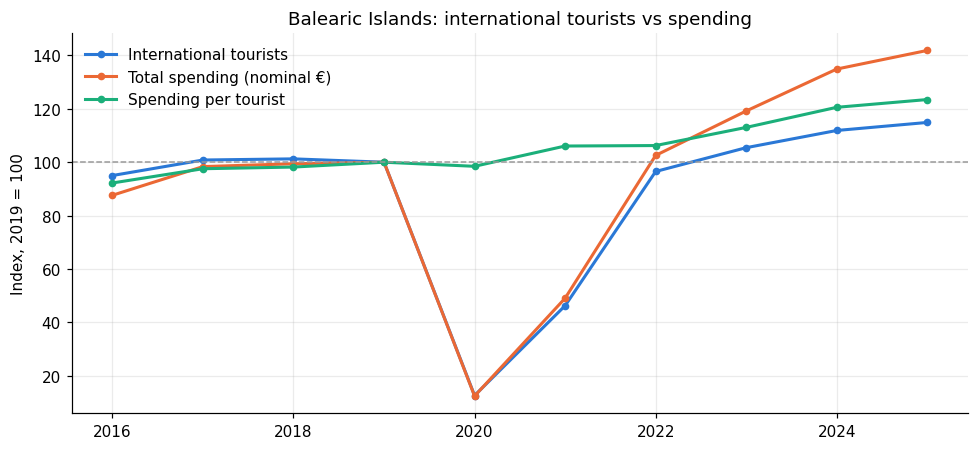

,tourists,spend_meur,spend_per_tourist_eur
year,,,
2019,13679781.0,14843.0,1085.0
2023,14424512.0,17692.0,1227.0
2024,15306312.0,20025.0,1308.0
2025,15717968.0,21060.0,1340.0


In [7]:
bi = intl.query("region == 'Balearic Islands' and 2016 <= year <= 2025").groupby("year")[["tourists", "spend_meur"]].sum()
bi["spend_per_tourist_eur"] = 1e6 * bi.spend_meur / bi.tourists
base = bi.loc[2019]
ix = 100 * bi / base
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(ix.index, ix.tourists, marker="o", lw=2, ms=4, color="#2a78d6", label="International tourists")
ax.plot(ix.index, ix.spend_meur, marker="o", lw=2, ms=4, color="#eb6834", label="Total spending (nominal €)")
ax.plot(ix.index, ix.spend_per_tourist_eur, marker="o", lw=2, ms=4, color="#1baf7a", label="Spending per tourist")
ax.axhline(100, color="#999", lw=1, ls="--")
ax.set(ylabel="Index, 2019 = 100", title="Balearic Islands: international tourists vs spending")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(IMG / "value_vs_volume.png"); plt.show()
bi.loc[[2019, 2023, 2024, 2025]].round(0)

Between 2019 and 2025 international tourists grew **+15%**, but their spending grew **+42%** (≈ €1,085 → €1,340 per tourist).
Part of this is inflation (these are nominal euros), but the islands are clearly growing more in **value** than in **volume**.

## 7. Who fills the hotels?

In [8]:
mix = (hotel.query("year == 2025 and market != 'All guests'")
            .groupby(["region", "market"])[["overnight_stays", "travellers"]].sum())
mix["avg_nights"] = mix.overnight_stays / mix.travellers
share_intl = (mix.xs("International", level=1).overnight_stays / mix.groupby(level=0).overnight_stays.sum() * 100)
pd.DataFrame({"international_share_%": share_intl.round(1),
              "avg_nights_international": mix.xs("International", level=1).avg_nights.round(2),
              "avg_nights_domestic": mix.xs("Domestic (Spain)", level=1).avg_nights.round(2)}).sort_values("international_share_%", ascending=False)

,international_share_%,avg_nights_international,avg_nights_domestic
region,,,
Balearic Islands,91.8,5.31,3.46
Canary Islands,87.2,7.16,3.85
Catalonia,72.3,2.99,2.09
Spain (total),66.7,3.83,2.23
Madrid,58.6,2.31,1.80
Andalusia,55.5,3.26,2.40
Valencian Community,52.3,3.61,2.73


**92% of Balearic hotel nights come from foreign guests**, who stay 5.3 nights on average versus 3.5 for Spanish residents — the market depends heavily on international demand.

## 8. Short-term outlook: can a model beat "same month last year"?
A forecast is only useful if it beats a simple baseline. I compare a **Holt-Winters** model (damped trend + monthly seasonality,
fitted on log nights since April 2022) with the **seasonal naive** baseline (next month = same month last year),
backtesting on the last 12 months available.

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
s = (hotel.query("market == 'All guests' and region == 'Balearic Islands'")
          .groupby("date").overnight_stays.sum().asfreq("MS"))
y = np.log(s["2022-04-01":]); n_test = 12
train, test = y[:-n_test], np.exp(y[-n_test:])
hw = ExponentialSmoothing(train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=12).fit()
f_hw = np.exp(hw.forecast(n_test)); f_sn = pd.Series(np.exp(train[-12:].values), index=test.index)
mape = lambda f: 100 * np.mean(np.abs(f.values - test.values) / test.values)
print(f"Backtest {test.index[0]:%b %Y}–{test.index[-1]:%b %Y}:  Holt-Winters MAPE {mape(f_hw):.1f}%  |  Seasonal naive MAPE {mape(f_sn):.1f}%")

Backtest Sep 2025–Aug 2026:  Holt-Winters MAPE 4.6%  |  Seasonal naive MAPE 4.4%


**Honest result:** the Holt-Winters model does *not* beat the seasonal naive baseline (≈4.6% vs ≈4.4% error).
With only four post-COVID years and a very stable seasonal pattern, "same month last year" is already a strong forecast.
The right recommendation is to use the simple baseline and spend modelling effort on drivers (flights, prices, events) instead.

## 9. Conclusions & recommendations
1. **Extreme seasonality is the main structural risk**: 66% of hotel nights in Jun–Sep, 48× peak-to-trough.
2. **Growth has moved to the shoulder season**: Apr, Oct and winter months grew 19–30% vs 2019 while summer grew ~5% —
   in 2026 the peak months are even slightly *below* 2025. Marketing, events and flight connectivity should target Apr–May and Oct.
3. **Value over volume**: spending per international tourist is up ~23% vs 2019 (nominal). Policies that favour higher-value,
   longer-staying visitors fit the data better than chasing more summer arrivals.
4. **Concentration risk**: 92% of hotel nights depend on foreign markets — worth tracking by source country next.

**Limitations:** hotels only (no holiday rentals), nominal euros (not inflation-adjusted), and regional aggregates (no island split).
**Next steps:** add country of origin, deflate spending with CPI, and an island-level view from IBESTAT.